In [3]:
import pandas as pd
import nfl_data_py as nfl
from data.data_aggregation import import_pbp_data
from simulation.drive_selection import select_drive
from simulation.overtime_period import Overtime_Period
import matplotlib.pyplot as plt
from simulation.rules import *
from simulation.simulate import *

In [10]:
df = simulate_overtimes(2025, 1000, go_for_ties=True, write_output=True)
df['Winning Team'].value_counts(normalize=True)


Winning Team
Receiving Team    0.463
Kicking Team      0.382
TIE               0.155
Name: proportion, dtype: float64

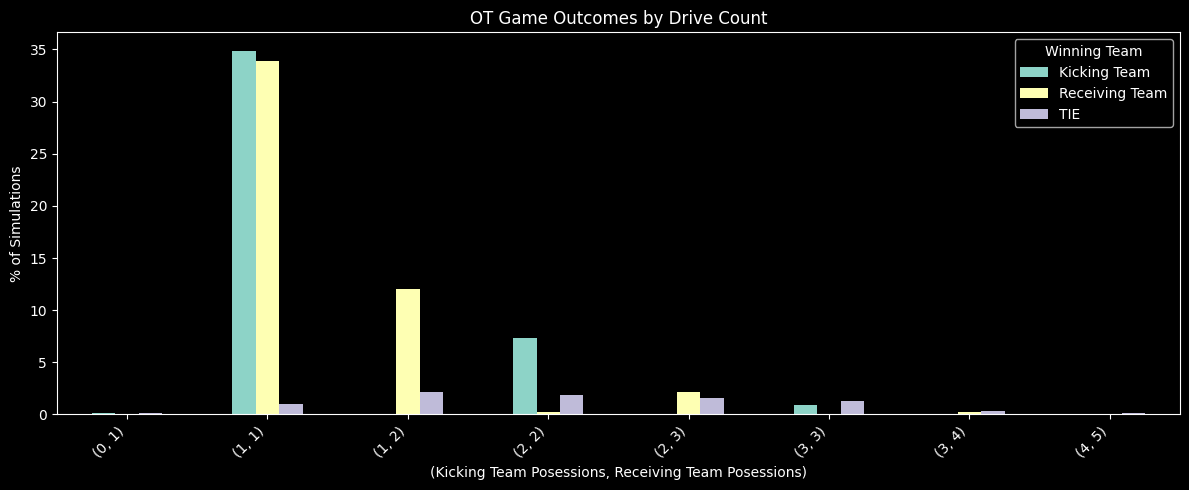

In [7]:
counts = (
    df.groupby(['Kicking Team Possessions', 'Receiving Team Possessions', 'Winning Team'])['Winning Team']
    .count()
    .unstack('Winning Team', fill_value=0)
)
pcts = counts / len(df) * 100

ax = pcts.plot(kind='bar', figsize=(12, 5))
ax.set_xlabel('(Kicking Team Posessions, Receiving Team Posessions)')
ax.set_ylabel('% of Simulations')
ax.set_title('OT Game Outcomes by Drive Count')
ax.legend(title='Winning Team')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

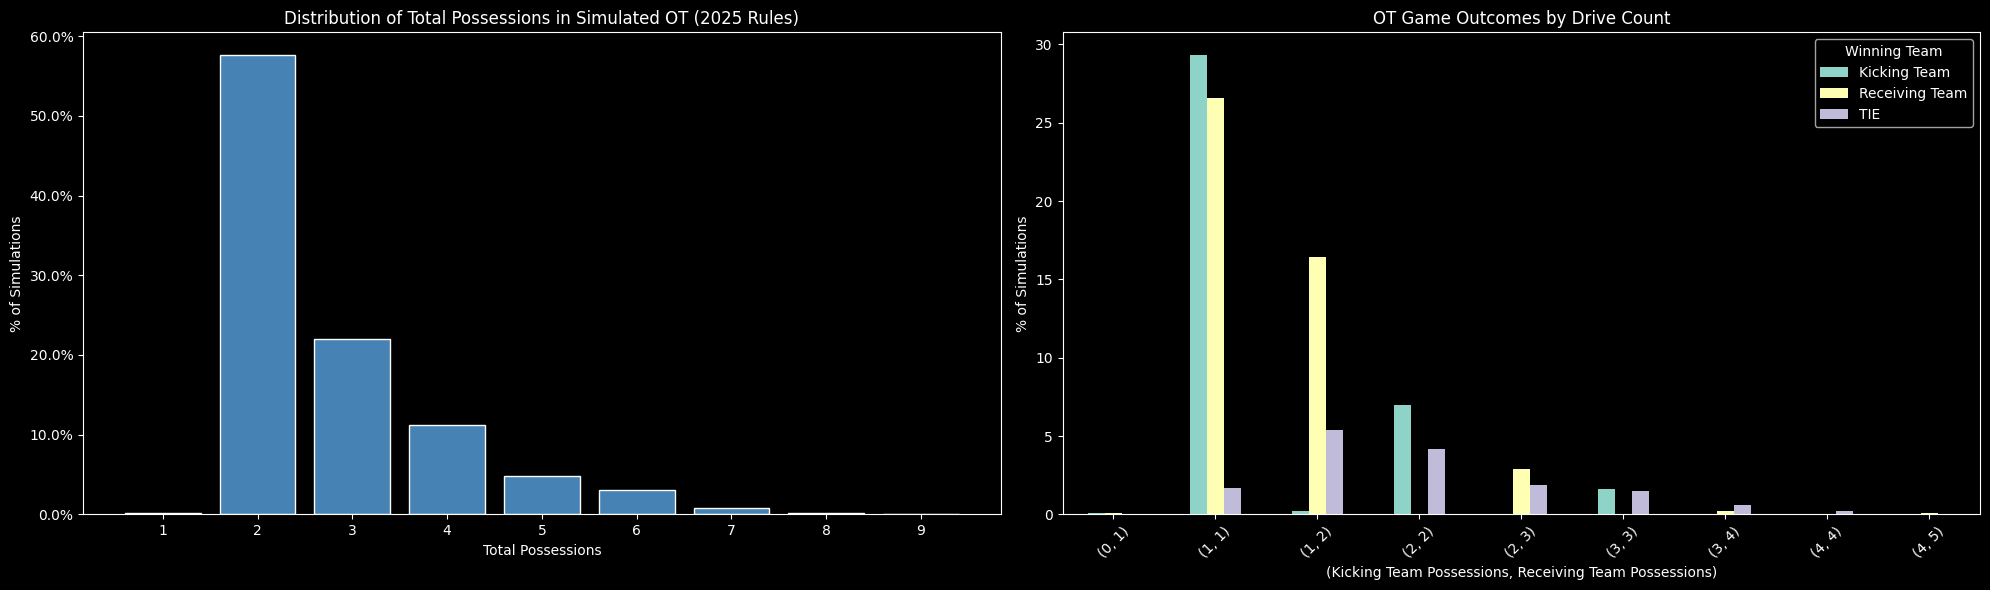

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

# Top: outcomes by drive count
counts = (
    df.groupby(['Kicking Team Possessions', 'Receiving Team Possessions', 'Winning Team'])['Winning Team']
    .count()
    .unstack('Winning Team', fill_value=0)
)
pcts = counts / len(df) * 100
pcts.plot(kind='bar', ax=ax2)
ax2.set_xlabel('(Kicking Team Possessions, Receiving Team Possessions)')
ax2.set_ylabel('% of Simulations')
ax2.set_title('OT Game Outcomes by Drive Count')
ax2.legend(title='Winning Team')
ax2.tick_params(axis='x', rotation=45)

# Bottom: total possession distribution
df['total_possessions'] = df['Kicking Team Possessions'] + df['Receiving Team Possessions']
possession_counts = df['total_possessions'].value_counts(normalize=True).sort_index() * 100
ax1.bar(possession_counts.index, possession_counts.values, color='steelblue', edgecolor='white')
ax1.set_xlabel('Total Possessions')
ax1.set_ylabel('% of Simulations')
ax1.set_title('Distribution of Total Possessions in Simulated OT (2025 Rules)')
ax1.set_xticks(possession_counts.index)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}%'))

plt.tight_layout()
plt.show()

In [38]:
DATA_DIR = r"C://Users//natel//PycharmProjects//NFL_Overtime_Model//data"
df = pd.read_pickle(f'{DATA_DIR}//pbp_data.pkl')
drive_list = pd.read_csv(f'{DATA_DIR}//drive_list.csv')
drive_list['season'] = drive_list['drive_id'].str[:4].astype(int)
ko_list = pd.read_csv(f"{DATA_DIR}//ko_list.csv")


In [ ]:
drive_list[drive_list['season'] == 2025]['drive_id'].sample(1)

In [ ]:
%%sql


In [ ]:
agg_results = {}

for season in [2023, 2024, 2025]:
    first_drive_results = []
    for _ in range(1000):
        OT = Overtime_Period('Kicking Team', 'Receiving Team', 'Kicking Team', season)  # was hardcoded to 2024
        OT.simulate()
        lines = OT.summary.split('\n')
        for line in lines:
            if ('scores a touchdown' in line or 'kicks a field goal' in line or
                'turns the ball over' in line or 'punts' in line):
                first_drive_results.append(line.strip())
                break
    agg_results[season] = pd.Series(first_drive_results).value_counts(normalize=True)

agg_df = pd.DataFrame(agg_results).fillna(0)
display(agg_df)

In [ ]:
df[(df['game_id'] == '2016_15_MIA_NYJ') & (df['drive'].isin([5,6]))][['drive','play_id','down','desc','game_seconds_remaining', 'play_duration']]


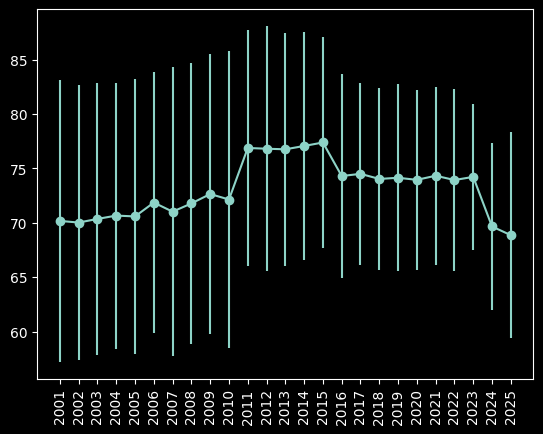

In [39]:
agg = ko_list.groupby('season')['starting_field_position'].agg(['mean', 'std'])
plt.errorbar(agg.index, agg['mean'], yerr=agg['std'], fmt='o-')
plt.xticks(agg.index.astype(int),rotation=90)

plt.show()

In [ ]:
print(agg)

In [37]:
results = {}
for season in  [2023, 2024, 2025]:
    fp = ko_list.groupby('season')['starting_field_position'].mean().loc[season]
    result, candidates = select_drive(drive_list, fp, overtime_length(season), 0, season)
    results[season] = candidates['drive_result'].value_counts(normalize = True)
display(pd.DataFrame(results).fillna(0))

NameError: name 'ko_list' is not defined

In [ ]:
drive_list[drive_list[('season')] == 2025]

In [ ]:
result, candidates = select_drive(drive_list, fp, 60, -3, season)
display(candidates)

In [ ]:
drive_list['season'] = drive_list['drive_id'].str[:4].astype(int)
print(drive_list.groupby('season')['drive_result']
      .apply(lambda x: (x == 'TOUCHDOWN').mean())
      .round(3))


In [ ]:
tied_drives = drive_list[drive_list['start_score_diff'] == 0]
print(tied_drives['drive_result'].value_counts(normalize=True))

In [ ]:
result = select_drive(drive_list, 25, 900, 0, 2011)
print(result)

In [ ]:
import pandas as pd

def get_ruleset(season, week):
    is_playoff = week > 18
    if season >= 2025:
        return '2025'
    elif season == 2024:
        return '2024'  # dynamic kickoff, old OT rules
    elif season >= 2022 and is_playoff:
        return '2025'  # playoff OT same as 2025 rules
    elif season >= 2017:
        return '2017_2023'  # 35-yard kickoff
    elif season == 2016:
        return '2016'  # 25-yard touchback
    elif season == 2015:
        return '2015'  # 10-min OT
    elif season >= 2012:
        return '2012_2014'  # FG-match era, 15-min OT
    else:
        return 'pre2012'  # pure sudden death

def aggregate_overtime_games(pbp: pd.DataFrame) -> pd.DataFrame:
    ot_plays = pbp[pbp['game_half'] == 'Overtime'].copy()

    results = []

    for game_id, game in ot_plays.groupby('game_id'):
        game = game.sort_values('play_id')

        first_play = game.iloc[0]
        season = first_play['season']
        week = first_play['week']
        receiving_team = first_play['posteam']

        home = first_play['home_team']
        away = first_play['away_team']
        kicking_team = away if receiving_team == home else home

        last_play = game.iloc[-1]
        home_score = last_play['total_home_score']
        away_score = last_play['total_away_score']

        if home_score > away_score:
            winner = home
        elif away_score > home_score:
            winner = away
        else:
            winner = 'TIE'

        results.append({
            'game_id': game_id,
            'season': season,
            'week': week,
            'ruleset': get_ruleset(season, week),
            'kicking_team': kicking_team,
            'receiving_team': receiving_team,
            'winner': winner,
            'kicking_team_won': winner == kicking_team,
            'receiving_team_won': winner == receiving_team,
            'tie': winner == 'TIE',
        })

    return pd.DataFrame(results).sort_values(['season', 'week']).reset_index(drop=True)

In [ ]:
drive_list['season'] = drive_list['drive_id'].str[:4].astype(int)


In [ ]:
pcts = (
  drive_list.groupby(['season','start_yardline'])['drive_result']
  .value_counts(normalize=True)
  .unstack(fill_value=0)
)

pcts['SCORING'] = pcts['TOUCHDOWN']+pcts['FIELD_GOAL']
pcts.to_csv('scoring_pct.csv')

In [ ]:
%%sql


In [ ]:
drives2025 = drive_list[(drive_list['season'] == 2025) & (~drive_list['drive_result'].isin(['END_GAME', 'END_HALF']))]
turnovers = drives2025['drive_result'].isin(['INTERCEPTION','FUMBLE', 'MISSED_FG', 'BLOCKED_FG', 'DOWNS', 'BLOCKED_PUNT']).sum()/len(drives2025)
time =drives2025['time_elapsed'].mean()
results = drives2025['drive_result'].value_counts(normalize=True)
print(f'Each drive takes on average {time:.0f} seconds')
print(f'Touchdown %: {results['TOUCHDOWN']*100:.2f}%')
print(f'Field Goal %: {results['FIELD_GOAL']*100:.2f}%')
print(f'Punt %: {results['PUNT']*100:.2f}%')
print(f'Turnover %: {turnovers*100:.2f}%')


In [ ]:
drive_list.groupby('start_yardline')['drive_result'].value_counts(normalize = True)

In [ ]:
ot_df = aggregate_overtime_games(df)

In [ ]:
ot_df.groupby(['ruleset']).agg(
    games=('game_id', 'count'),
    receiving_won=('receiving_team_won', 'sum'),
    kicking_won=('kicking_team_won', 'sum'),
    ties=('tie', 'sum'),
    receiving_pct=('receiving_team_won', 'mean'),
    kicking_pct=('kicking_team_won', 'mean'),
    tie_pct=('tie', 'mean'),
).round(3).T
